In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df=pd.read_csv("C:\\Users\\Neha\\Downloads\\warehouse_inventory_clustering_dataset.csv")

In [6]:
df.head()

,item_id,category,subcategory,supplier_id,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,ITM00001,Grocery,Snacks,S1036,B2,310,0.26,7.8,0.05,8,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,ITM00002,Industrial,Electrical Parts,S1036,B1,455,0.16,4.8,0.08,8,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,ITM00003,Apparel,Jackets,S1011,B2,350,0.43,20.9,0.57,6,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,ITM00004,Automotive,Lubricants,S1030,A1,121,0.33,4.6,0.12,1,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,ITM00005,Pharmaceutical,Medical Devices,S1064,A2,85,0.14,7.3,0.15,1,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [7]:
df=df.drop(['item_id','supplier_id'],axis=1)

In [8]:
df.head()

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,Grocery,Snacks,B2,310,0.26,7.8,0.05,8,9.71,33,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,Industrial,Electrical Parts,B1,455,0.16,4.8,0.08,8,11.55,26,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,Apparel,Jackets,B2,350,0.43,20.9,0.57,6,3.69,27,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,Automotive,Lubricants,A1,121,0.33,4.6,0.12,1,0.54,120,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,Pharmaceutical,Medical Devices,A2,85,0.14,7.3,0.15,1,1.46,97,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   category                         4000 non-null   object 
 1   subcategory                      4000 non-null   object 
 2   warehouse_zone                   4000 non-null   object 
 3   avg_monthly_demand               4000 non-null   int64  
 4   demand_variability               4000 non-null   float64
 5   avg_lead_time_days               4000 non-null   float64
 6   lead_time_variability            4000 non-null   float64
 7   monthly_reorder_count            4000 non-null   int64  
 8   stock_turnover_ratio             4000 non-null   float64
 9   days_in_inventory                4000 non-null   int64  
 10  stockout_frequency               4000 non-null   int64  
 11  backorder_frequency              4000 non-null   int64  
 12  return_rate         

In [10]:
df.isnull().sum()

category                           0
subcategory                        0
warehouse_zone                     0
avg_monthly_demand                 0
demand_variability                 0
avg_lead_time_days                 0
lead_time_variability              0
monthly_reorder_count              0
stock_turnover_ratio               0
days_in_inventory                  0
stockout_frequency                 0
backorder_frequency                0
return_rate                        0
damage_rate                        0
holding_cost_per_unit              0
unit_cost                          0
reorder_point_breaches             0
supplier_delay_incidents           0
current_stock                      0
safety_stock                       0
excess_stock_level                 0
inventory_value                    0
warehouse_demand_pressure_index    0
dtype: int64

In [11]:
df.describe(include='all')

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
count,4000,4000,4000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4000.00000
unique,8,40,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Automotive,Batteries,C1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,527,125,546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,331.809250,0.285640,10.301275,0.258738,4.707250,5.944282,65.489750,...,0.015713,47.709973,804.380267,2.657250,3.239750,317.102000,80.002750,104.915750,2.491254e+05,159.10009
std,NaN,NaN,NaN,228.438284,0.128173,5.592473,0.165963,2.991118,3.804082,56.855528,...,0.008412,50.174326,741.472968,3.498976,3.615873,136.958627,55.192937,106.302228,2.508303e+05,88.27321
min,NaN,NaN,NaN,1.000000,0.080000,1.000000,0.050000,0.000000,0.200000,4.000000,...,0.002000,0.520000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000e+00,5.00000
25%,NaN,NaN,NaN,103.000000,0.190000,6.200000,0.130000,2.000000,2.140000,22.000000,...,0.009000,12.565000,220.160000,0.000000,0.000000,219.000000,27.000000,32.000000,6.278350e+04,82.77000
50%,NaN,NaN,NaN,333.000000,0.260000,9.000000,0.200000,5.000000,6.150000,34.000000,...,0.015000,33.710000,652.130000,1.000000,2.000000,304.000000,80.000000,60.000000,1.759532e+05,151.79500
75%,NaN,NaN,NaN,523.250000,0.370000,13.400000,0.360000,7.000000,9.140000,106.000000,...,0.020000,64.495000,1108.817500,4.000000,5.000000,403.000000,122.000000,150.000000,3.498038e+05,228.21000


In [12]:
df.duplicated().sum()

np.int64(0)

# -**Features Information**

- **item_id – Unique identifier for each item**
- **category – Product category**
- **subcategory – Product subcategory**
- **supplier_id – Supplier identifier**
- **warehouse_zone – Storage location**
- **avg_monthly_demand – Average demand per month**
- **demand_variability – Variation in demand**
- **avg_lead_time_days – Average supplier lead time**
- **lead_time_variability – Variation in lead time**
- **monthly_reorder_count – Number of reorders per month**
- **stock_turnover_ratio – Inventory turnover rate**
- **days_in_inventory – Days item stays in warehouse**
- **stockout_frequency – Frequency of stockouts**
- **backorder_frequency – Frequency of backorders**
- **return_rate – Return percentage**
- **damage_rate – Damage percentage**
- **holding_cost_per_unit – Cost to hold one unit**
- **unit_cost – Cost per unit**
- **reorder_point_breaches – Times reorder level failed**
-  **supplier_delay_incidents – Supplier delay occurrences**
- **current_stock – Current stock level**
- **safety_stock – Safety stock maintained**
- **excess_stock_level – Overstock quantity**
- **inventory_value – Total value of inventory**
- **warehouse_demand_pressure_index – Combined operational pressure metric**

# - **Visualizations**

# -**Univariate Analysis**

In [13]:
numcol = df.select_dtypes(include=['int64','float64']).columns.tolist()

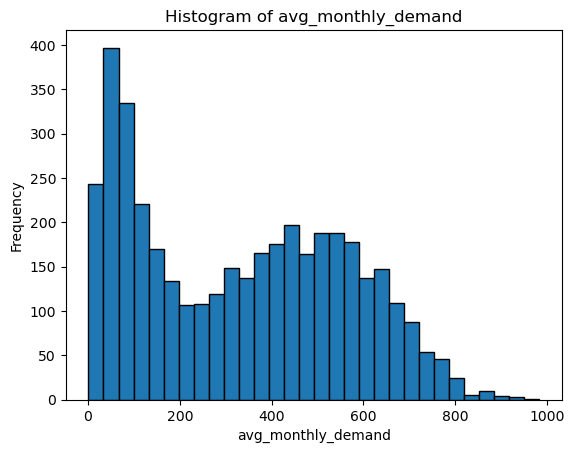

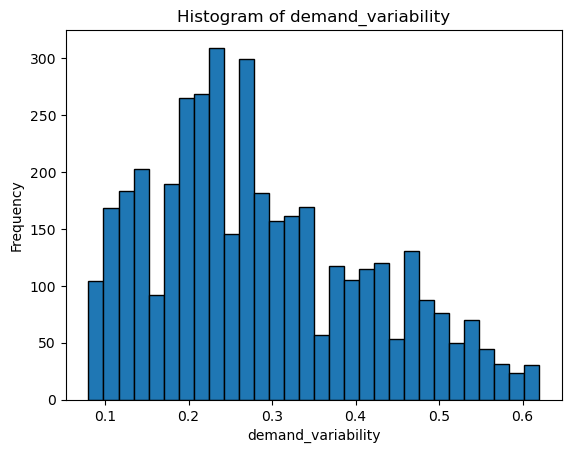

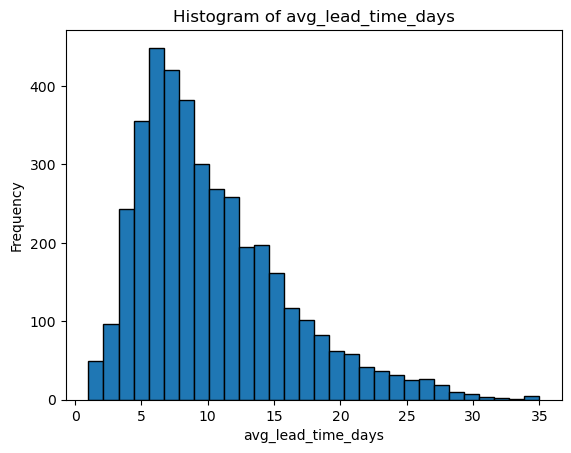

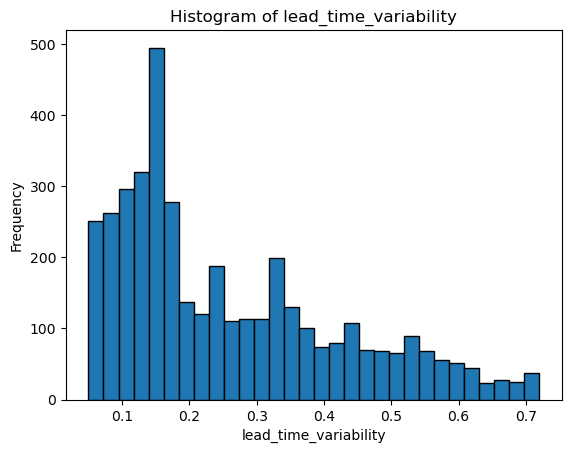

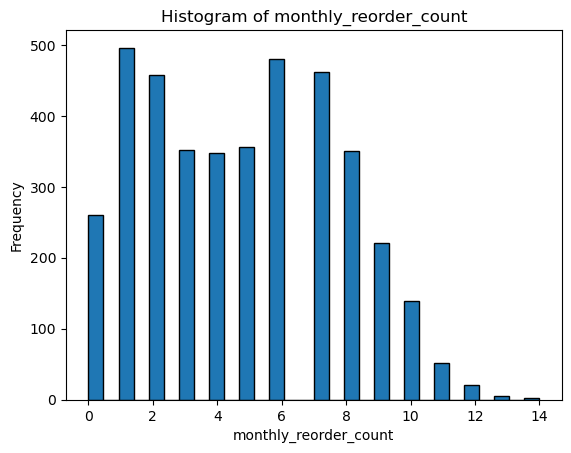

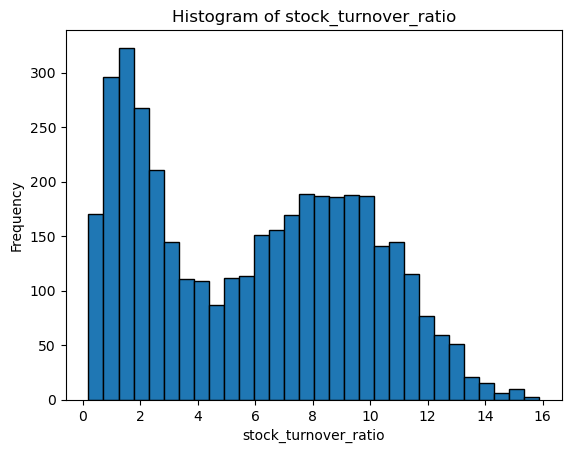

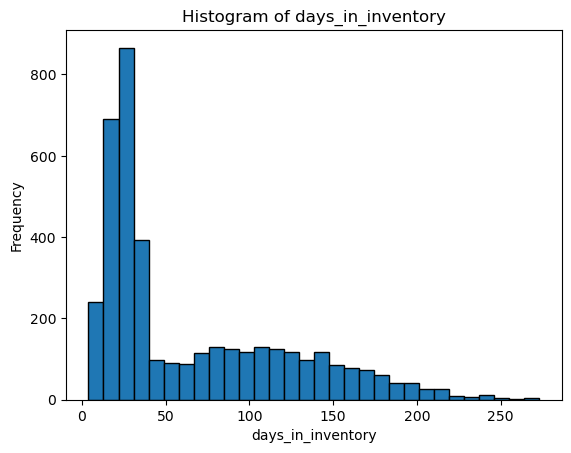

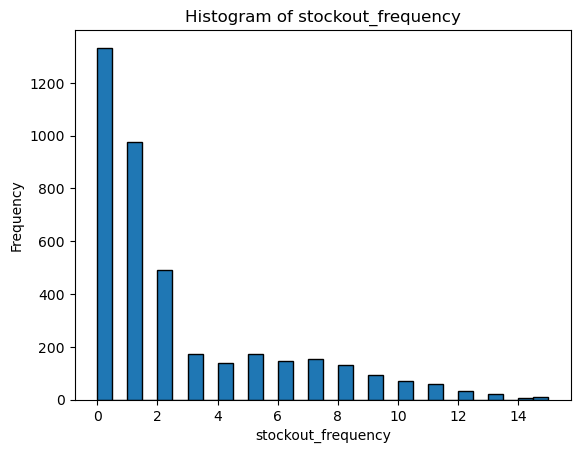

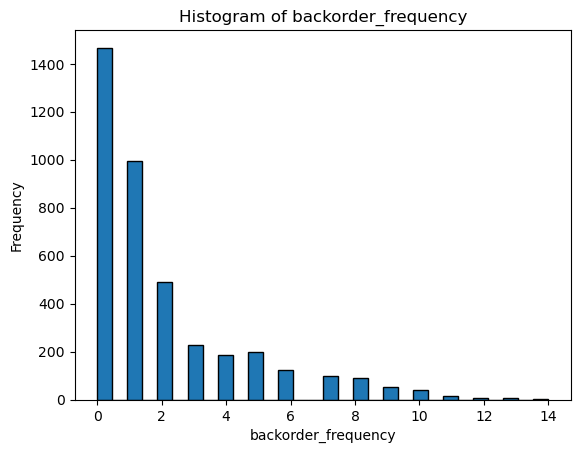

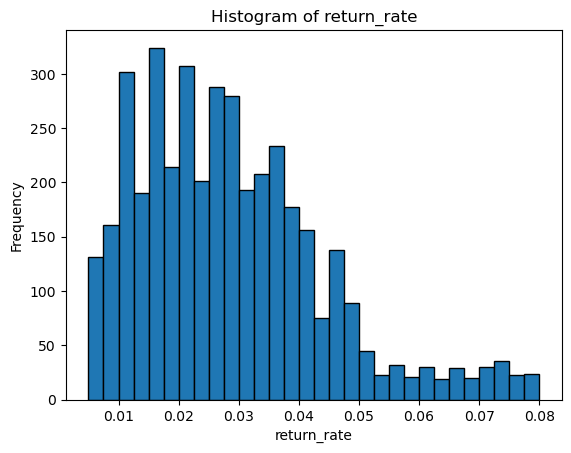

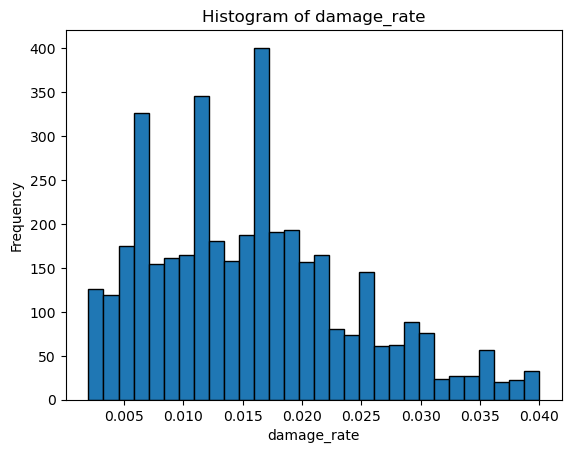

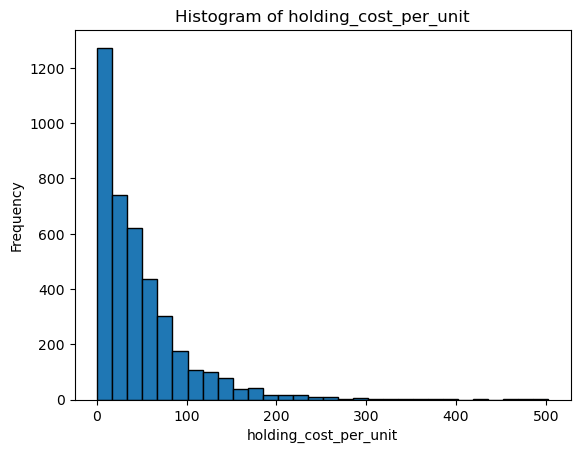

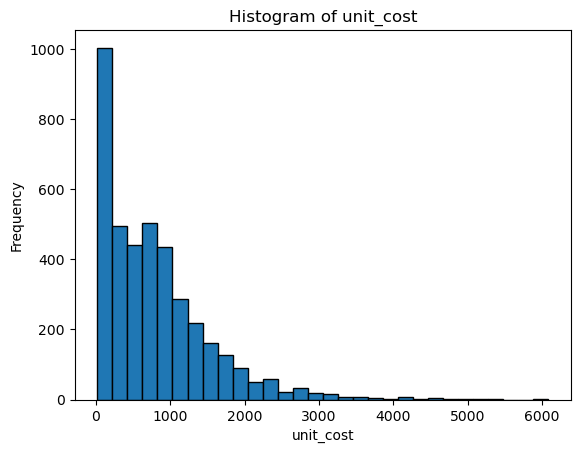

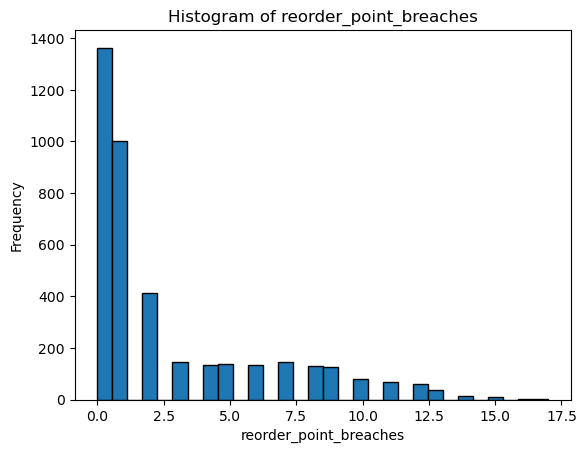

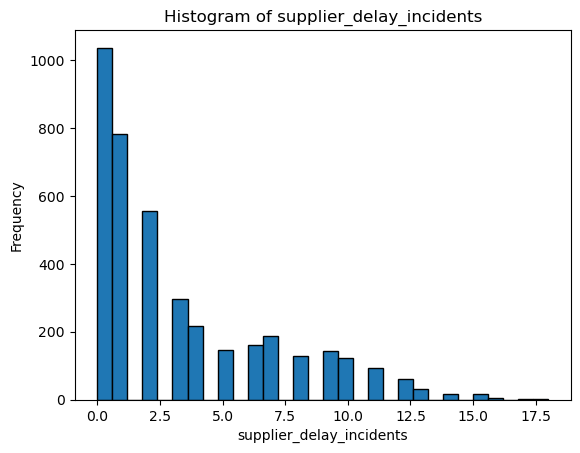

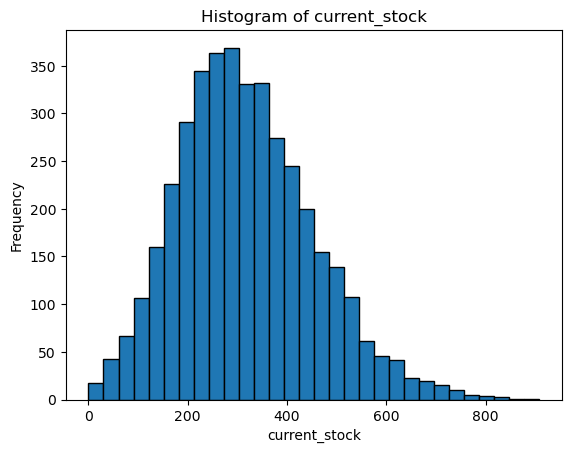

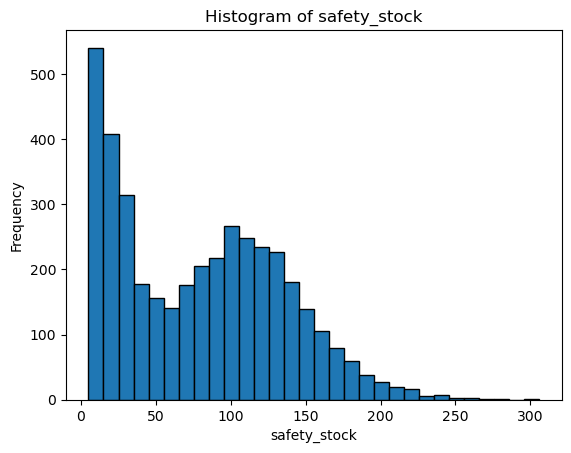

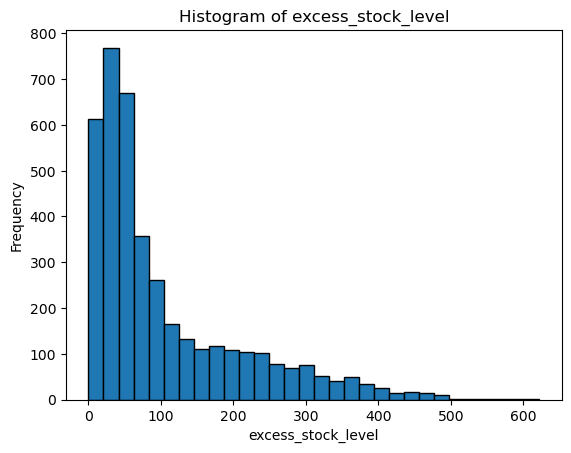

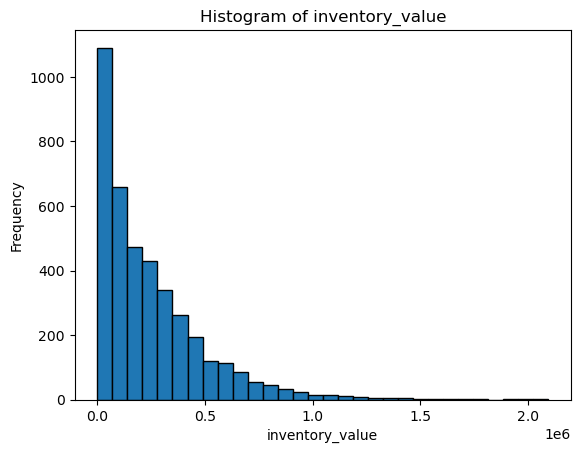

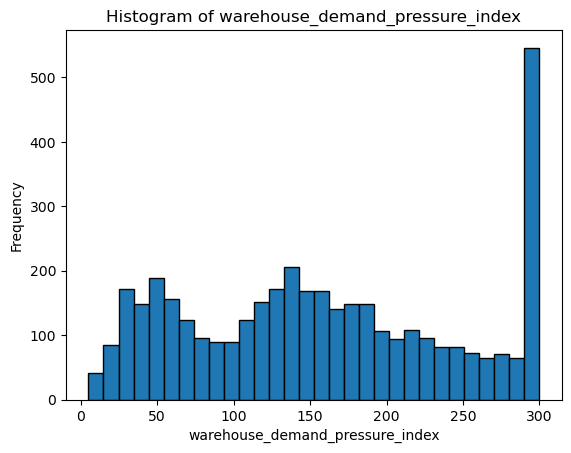

In [14]:
for col in numcol:
    plt.figure()
    plt.hist(df[col], bins=30,edgecolor='Black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Distribution of histogram
**1.Distribution of avg monthly demand -**
- Highest average demand per month between 0-100 has highest frequency around 1000.
- Lowest average demand per month between 100-1000 has lowest frequency around 600.**
- The distribution is right skewed.

**2. Distribution of demand variability -**
- Highest Variation in demand between 0.2-0.1 has highest frequency above 800.
- Lowest Variation in demand between 0.4-0.6 has lowest frequency around 300.**
- The distribution is right skewed.

**3. Distribution of avg lead time days -**
- Highest average Average supplier lead time between 5-7 has highest frequency around 1200.
- Lowest average Average supplier lead time between 0-5 and 7-35 has lowest frequency around 400.**
- The distribution is right skewed.

**4. Distribution of lead time variability -**
- Highest Variation in lead time between 0.1-0.2 has highest frequency above 1000.
- Lowest Variation in lead time between 0.2-0.7 has lowest frequency around 400.**
- The distribution is right skewed.

**5. Distribution of monthly reorder count -**
- Highest Number of reorders per month between 0-8 has highest frequency above 300.
- Lowest Number of reorders per month between 8-14 has lowest frequency less than 200.**
- The distribution is multi model distribution.

**6. Distribution of stock turnover ratio -**
- Highest Inventory turnover rate between 0-3 has highest frequency above 600.
- Lowest Inventory turnover rate between 3-16 has lowest frequency less than 600.**
- The distribution is multi model distribution.

**7. Distribution of days in inventory -**
- Highest Days item stays in warehouse between 0-30 has highest frequency around 1750.
- Lowest Days item stays in warehouse between 30-250 has lowest frequency less than 600.**
- The distribution is right skewed.

**8. Distribution of stockout frequency -**
- Highest Frequency of stockouts between 0-2 has highest frequency above 2000.
- Lowest Frequency of stockouts between 2-14 has lowest frequency less than 500.**
- The distribution is right skewed.

**9. Distribution of backorder frequency -**
- Highest Frequency of backorders between 0-2 has highest frequency above 2000.
- Lowest Frequency of stockouts between 2-14 has lowest frequency less than 500.**
- The distribution is right skewed.

**10. Distribution of return rate -**
- Highest return percentage between 0.01-0.04 has highest frequency above 500.
- Lowest return percentage between 0.04-0.08 has lowest frequency less than 300.**
- The distribution is right skewed.

**11. Distribution of damage rate -**
- Highest Damage percentage between 0.005-0.015 has highest frequency above 600.
- Lowest Damage percentage between 0.017-0.040 has lowest frequency less than 300.**
- The distribution is right skewed.

**12. Distribution of holding cost per unit -**
- Highest Cost to hold one unit between 0-50 has highest frequency above 2500.
- Lowest Cost to hold one unit between 50-500 has lowest frequency less than 1000.**
- The distribution is right skewed.

**13. Distribution of unit cost -**
- Highest Cost per unit between 0-1100 has highest frequency above 1000.
- Lowest Cost per unit between 1100-6000 has lowest frequency less than 500.**
- The distribution is right skewed.

**14. Distribution of reorder point breaches -**
- Highest Times reorder level failed between 0.0-1.5 has highest frequency above 2000.
- Lowest Times reorder level failed between 1.5-17.5 has lowest frequency less than 500.**
- The distribution is right skewed.

**15. Distribution of supplier delay incidents -**
- Highest Supplier delay occurrences between 0.0-1.5 has highest frequency above 1750.
- Lowest Supplier delay occurrences between 1.5-17.5 has lowest frequency less than 1000.**
- The distribution is right skewed.

**16. Distribution of current stock -**
- Highest Current stock level between 200-380 has highest frequency around 1000.
- Lowest Current stock level between 0-200 and 380-800 has lowest frequency less than 800.**
- The distribution is Normal distribution.

**17. Distribution of safety stock -**
- Highest Safety stock maintained between 0-25 has highest frequency above 1200.
- Lowest Safety stock maintained between 25-300 has lowest frequency less than 800.**
- The distribution is multi model distribution.

**18. Distribution of excess stock level -**
- Highest Overstock quantity between 0-50 has highest frequency above 2000.
- Lowest Overstock quantity between 50-600 has lowest frequency less than 750.**
- The distribution is right skewed.

**19. Distribution of inventory value -**
- Highest Total value of inventory between 0.0-0.2 has highest frequency above 2000.
- Lowest Total value of inventory between 0.2-2.0 has lowest frequency less than 1000.**
- The distribution is right skewed.

**20. Distribution of warehouse demand pressure index -**
- Highest Combined operational pressure metric between 25-75, 125-150 and 275-300 has highest frequency above 500.
- Lowest Combined operational pressure metric between 0-25, 75-125 and 150-275 has lowest frequency less than 500.**
- The distribution is multi model distribution.

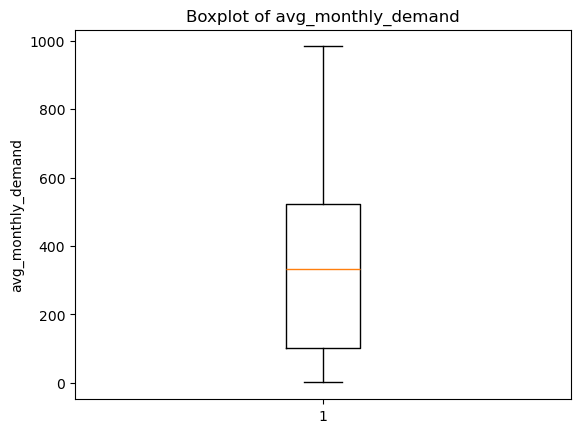

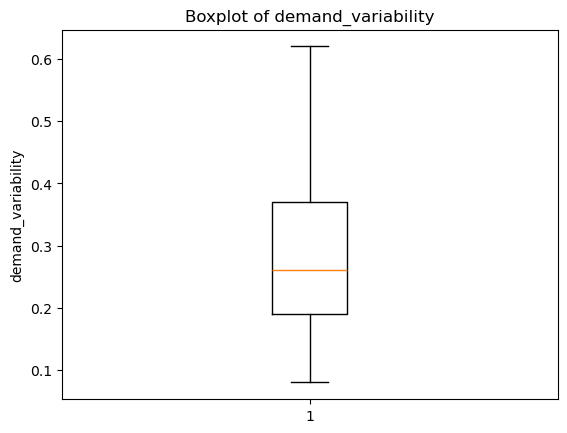

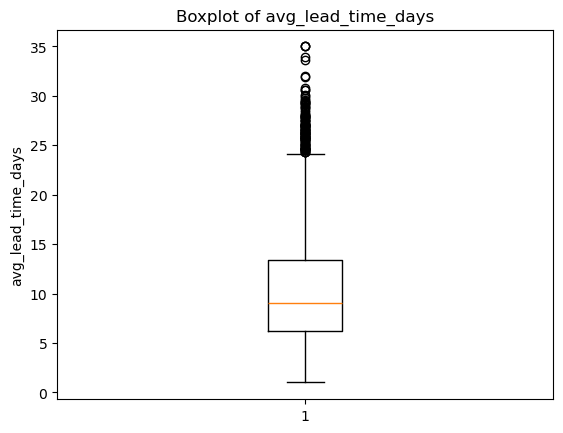

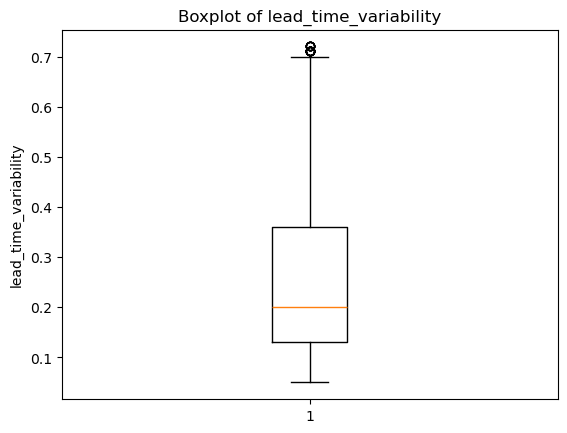

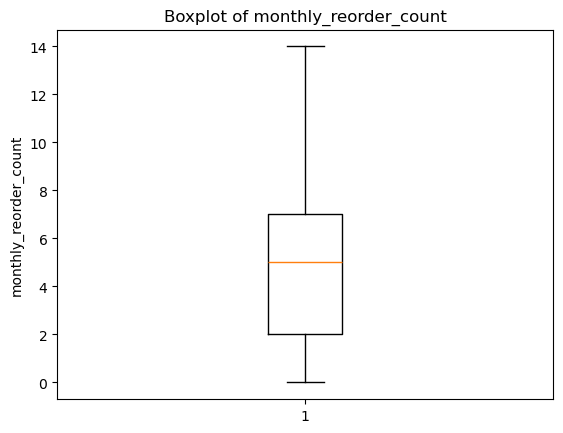

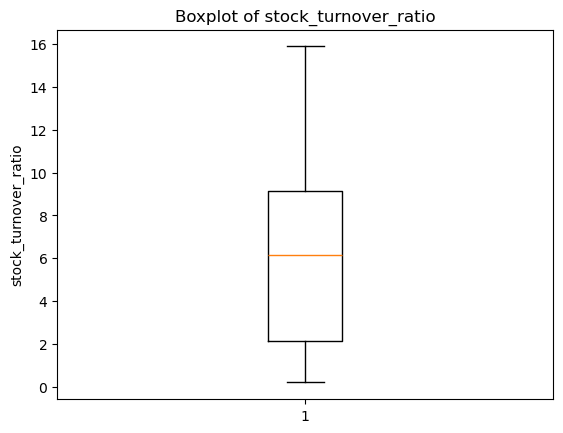

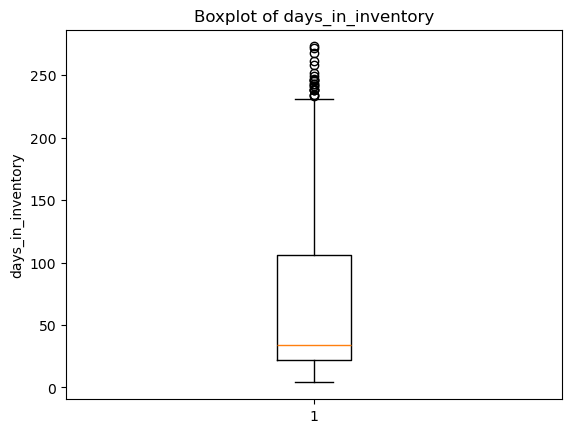

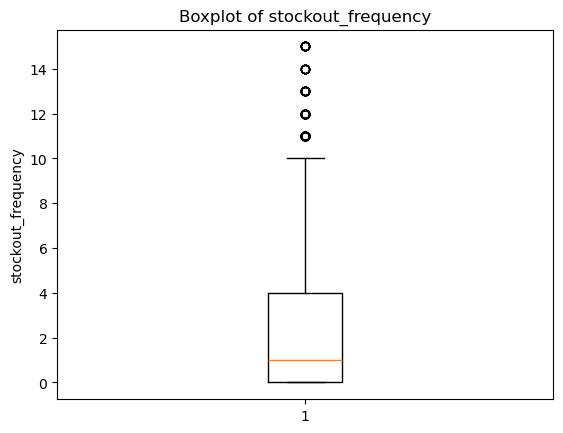

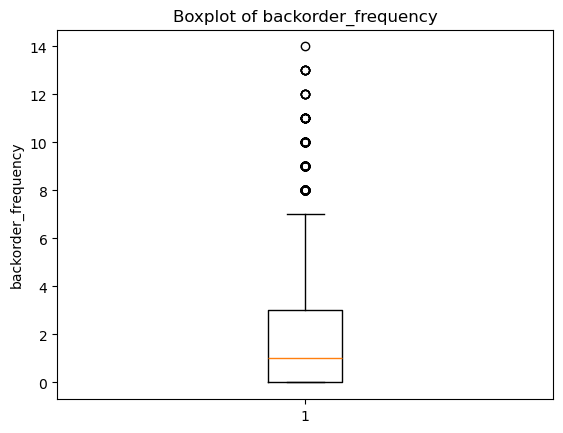

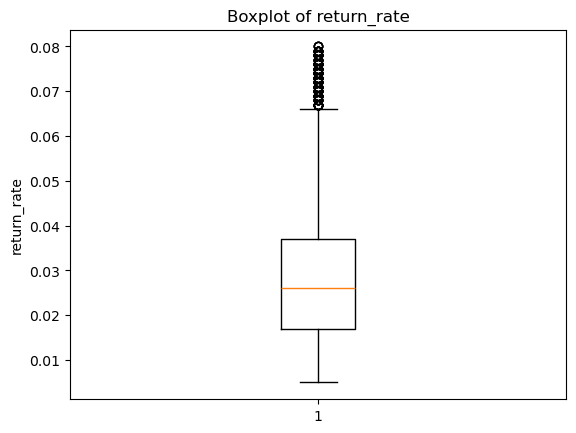

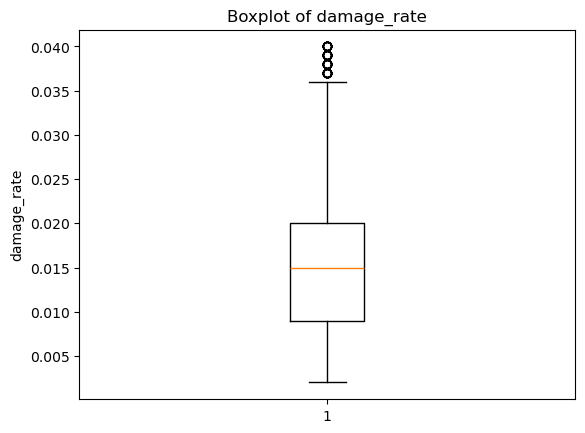

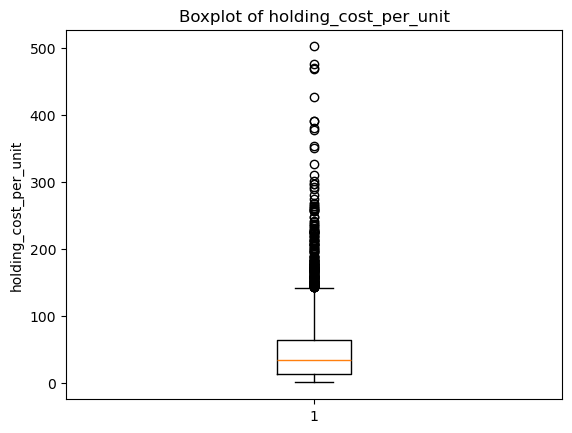

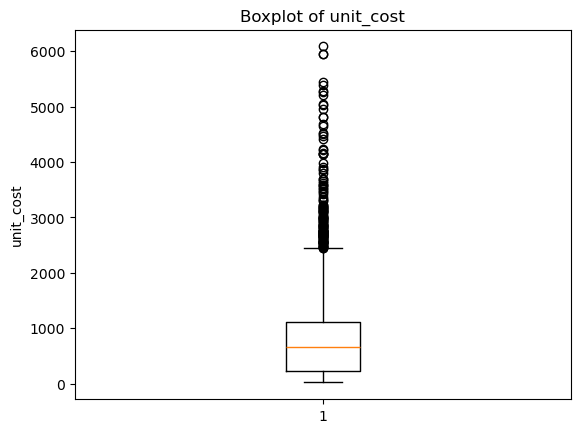

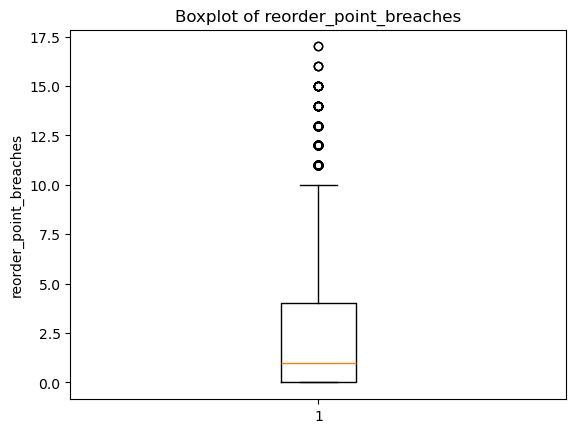

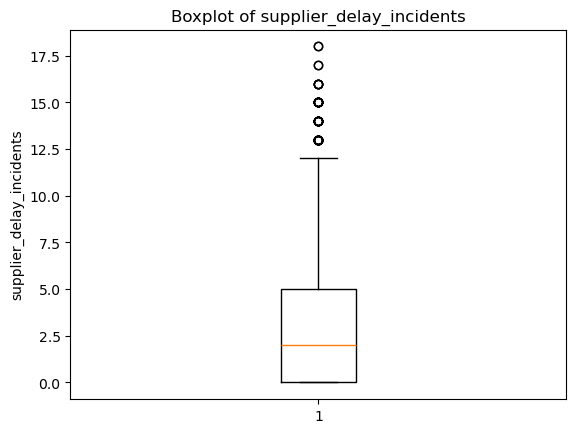

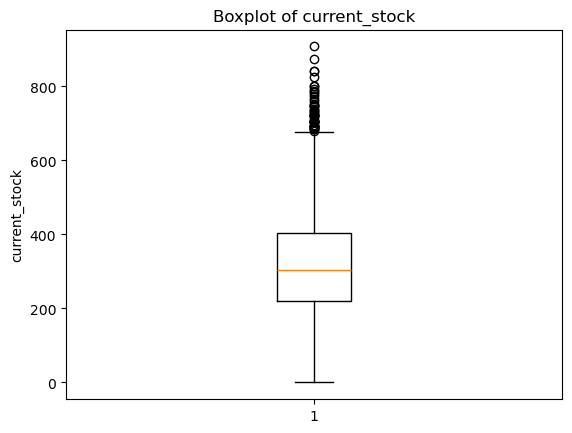

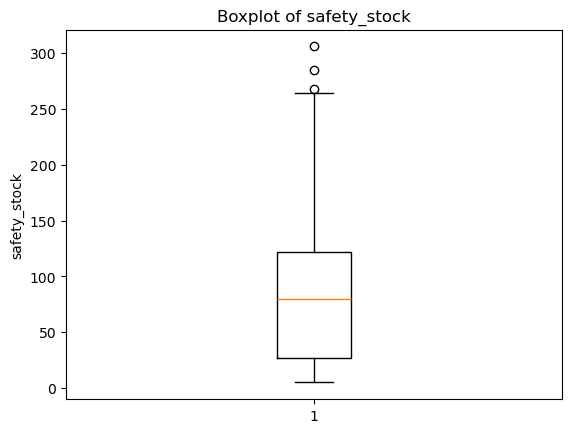

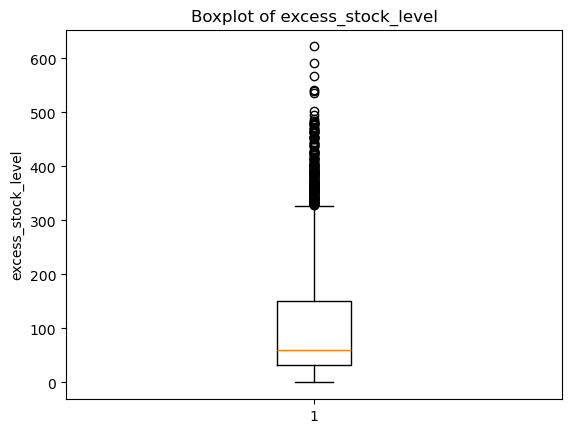

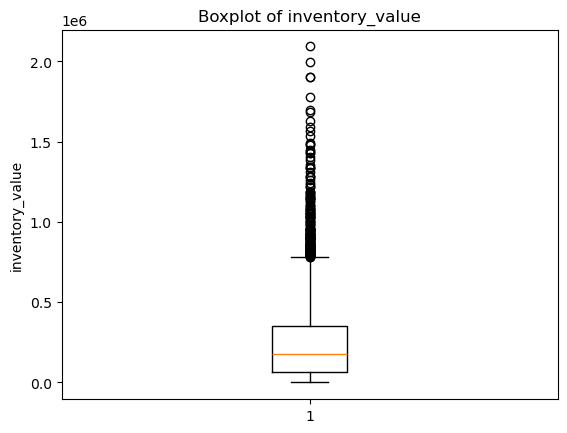

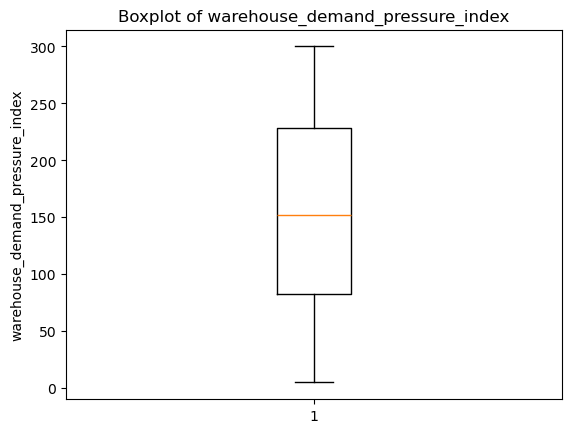

In [15]:
for col in numcol:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

# Box plot of Features.
**1.The boxplot summarizes that the distribution of avg_monthly_demand.**
-  The line inside the box is around 380 demand .This means 50% of average monthly demand are below 380 demand.
    
 **2.The boxplot summarizes that the distribution of demand variability.**
- The  line inside the box is around 0.3.This means 40% of demand variability are below 0.3 hours.
    
 **3.The boxplot summarizes that the distribution of avg_lead_time_days.**
-  The line inside the box is around 5.8 delays .This means 20% of average lead times are below 5.8 delays.
-  The dataset shows high-value outliers(25-35).

 **4.The boxplot summarizes that the distribution of lead_time_variability.**
- The line inside the box is around 0.2 variability.This means 30% of time variability are below 0.2 variability.
- The dataset shows high-value outliers(0.7).

 **5.The boxplot summarizes that the distribution of monthly_reorder_count.**
- The line inside the box is around 5 reorder count .This means 80% of reorder count are below 5.

 **6.The boxplot summarizes that the distribution of stock_turnover_ratio.**
- The line inside the box is around 6 turnover ratio.This means 60% of turnover ratio are below 6.

**7.The boxplot summarizes that the distribution of days_in_inventory.**
- The line inside the box is around 20.This means 10% of days in inventory are below 20.
- The dataset shows high-value outliers(200).

**8.The boxplot summarizes that the distribution of stockout_frequency.**
- The line inside the box is around 1 frequency.This means 20% of stockout frequency are below 1.
- The dataset shows high-value outliers(11-14).
   
 **9.The boxplot summarizes that the distribution of backorder_frequency.**
- The line inside the box is around 1 frequency .This means 20% of backorder frequency are below 1.
- The dataset shows high-value outliers(8-14).

 **10.The boxplot summarizes that the distribution of return_rate.**
- The line inside the box is around 20 rate.This means 30% of return rate are below 20.
- The dataset shows high-value outliers(0.7 - 0.8).

 **11.The boxplot summarizes that the distribution of damage_rate.**
- The line inside the box is around 0.015 rate.This means 50% of damage rate are below 0.015.
- The dataset shows high-value outliers(0.038-0.040).

 **12.The boxplot summarizes that the distribution of holding_cost_per_minute.**
- The line inside the box is around 50.This means 10% of holding cost per minute are below 50.
- The dataset shows high-value outliers(50-500).

 **13.The boxplot summarizes that the distribution of unit cost.**
- The line inside the box is around 20 frequency.This means 20% of unit cost are below 20.
- The dataset shows high-value outliers(2500-6000).

 **14.The boxplot summarizes that the distribution of reorder_point_breaches.**
- The line inside the box is around 0.15 frequency.This means 20% of reorder point breaches are below 0.15.
- The dataset shows high-value outliers(11-17.5).

 **15.The boxplot summarizes that the distribution of supplier_delay_incidents.**
- The center line inside the box is around 20 frequency.This means 20% of supplier delay incidents are below 20.
- The dataset shows high-value outliers(11-14).

 **16.The boxplot summarizes that the distribution of current_stock.**
- The center line inside the box is around 300 stock.This means 50% of current stock are below 300.
- The dataset shows high-value outliers(700-900).

 **17.The boxplot summarizes that the distribution of safety_stock.**
- The center line inside the box is around 7 stock.This means 60% of safety stock are below 7.
- The dataset shows high-value outliers(280-310).

 **18.The boxplot summarizes that the distribution of excess_stock_level.**
- The center line inside the box is around 50 stock level.This means 10% of excess stock level are below 50.
- The dataset shows high-value outliers(350-610).

 **19.The boxplot summarizes that the distribution of inventory_value.**
- The center line inside the box is around 0.2 inventory value.This means 10% of inventory value are below 0.2.
- The dataset shows high-value outliers(0.8-2.1).

 **20.The boxplot summarizes that the distribution of warehouse_demand_pressure_index.**
- The center line inside the box is around 150 warehouse demand pressure index.This means 50% of warehouse demand pressure index are below 150.

In [16]:
categorycol = ['category','subcategory','warehouse_zone']

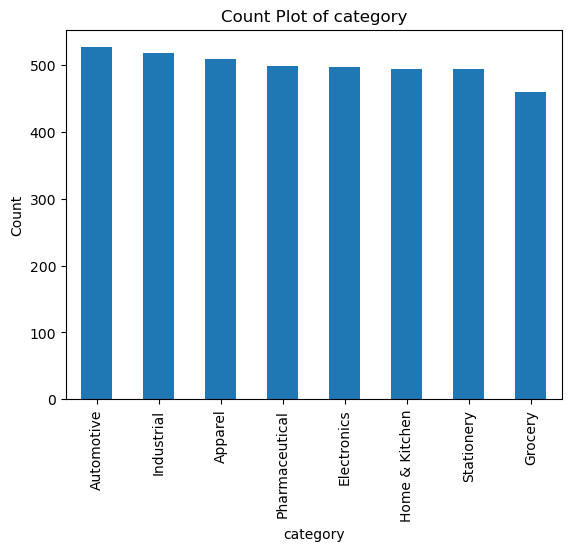

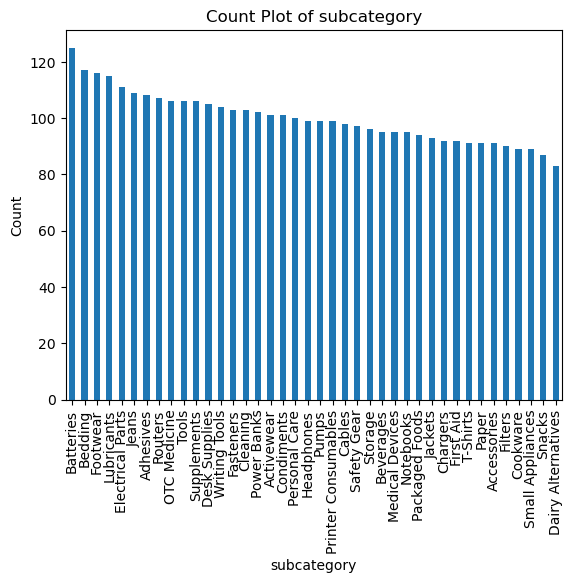

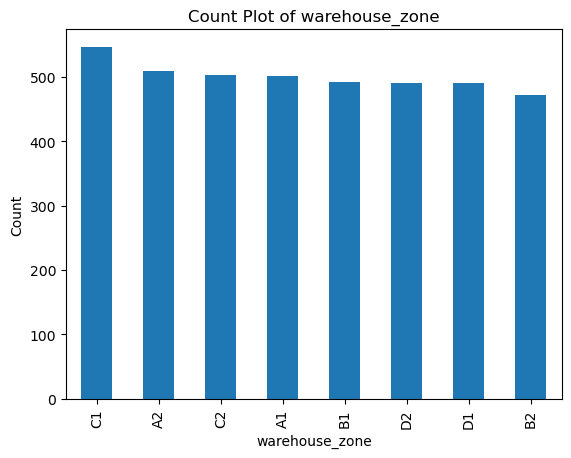

In [17]:
for col in categorycol:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Distribution of Count Plot
**1. Distribution of category -**
- Category like industrial and Automotive has the highest count around 500.
- Category like Grocery has the lowest count around 450.

**2. Distribution of subcategory -**
- Subcategory like Electrical parts, lubricants, Batteries, Bedding and Footwear has the highest count above 500.
- Subcategory like Snacks, Jackets, Medical Device, Storage, Dairy Alternavtives, First Aid, Filters, Accessories, Small Appliance, Cookware, Paper, Packaged Foods, Cleaning, Beverages and Chargers has the lowest count less than 100.

**3. Distribution of warehouse zone -**
- warehouse zone like C1 has the highest count above 500.
- warehouse zone like B2, B1, A1, A2, D2, D1 and C2 has the lowest count less than 500.

# -**Bivariate Analysis**

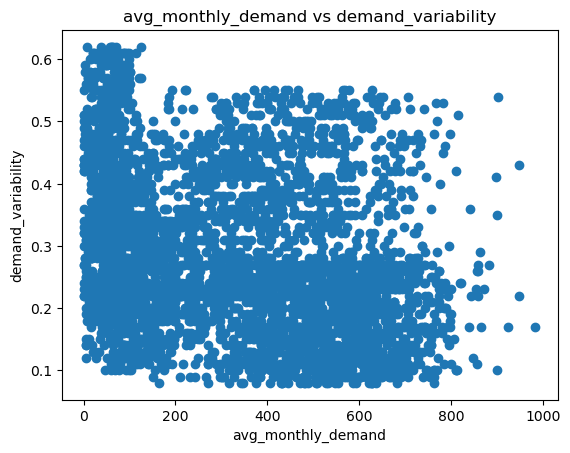

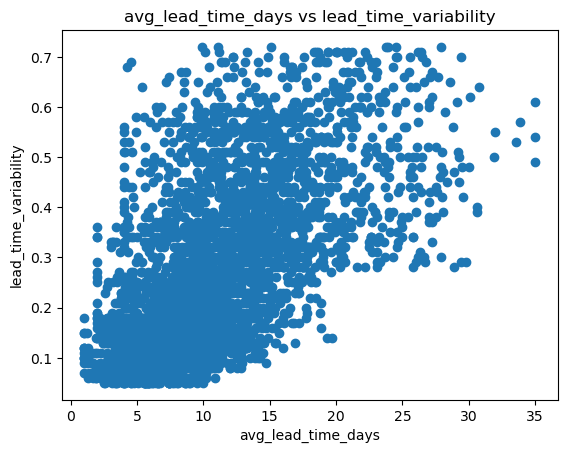

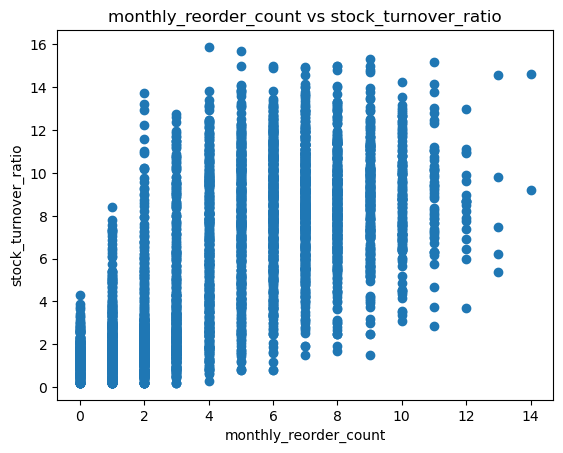

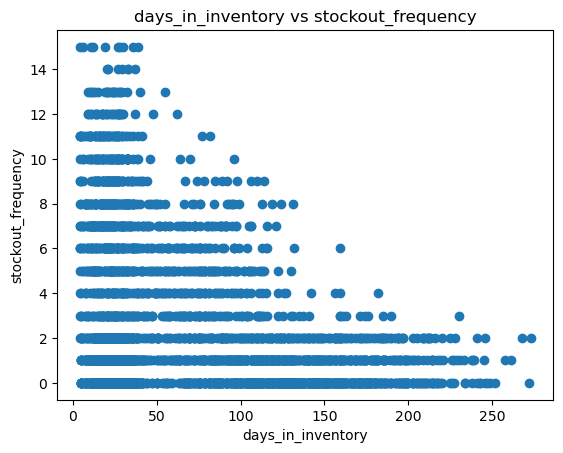

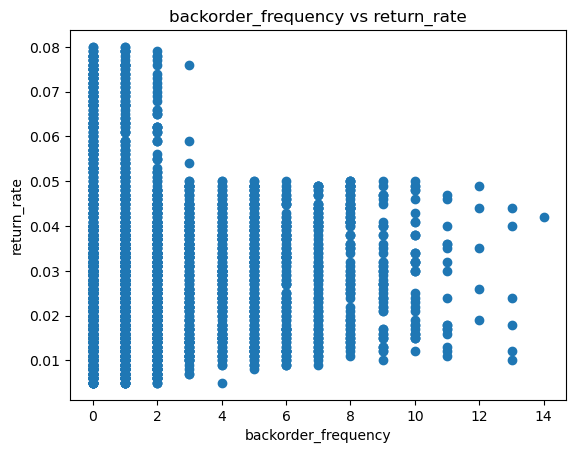

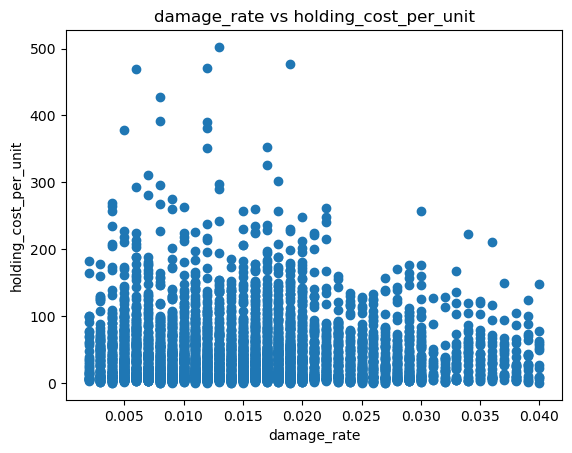

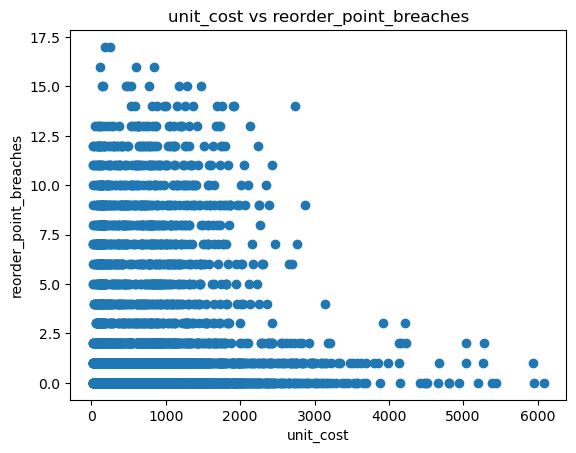

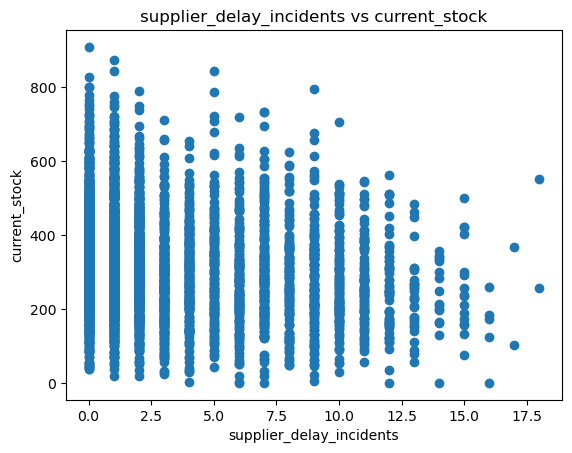

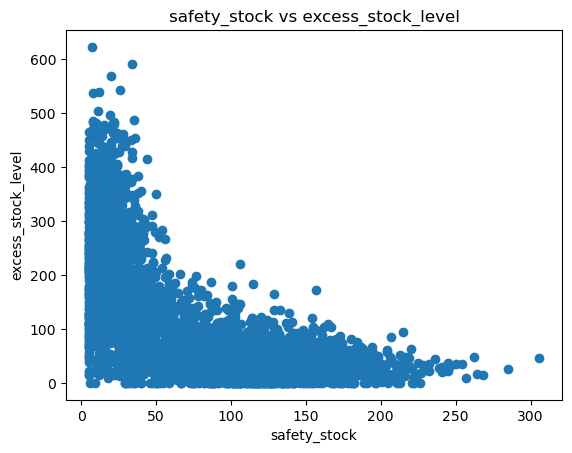

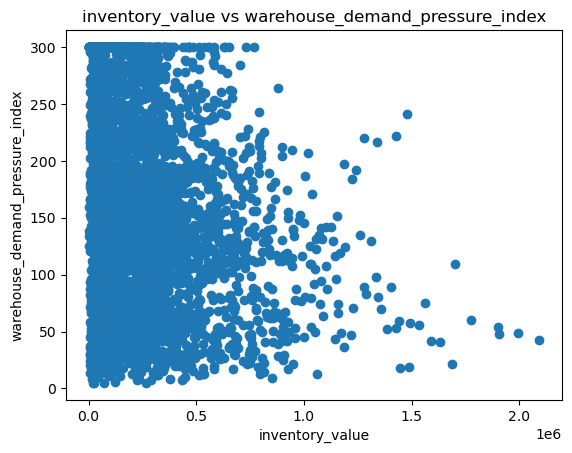

In [24]:
pairs = [
    ('avg_monthly_demand','demand_variability'),
    ('avg_lead_time_days','lead_time_variability'),
    ('monthly_reorder_count','stock_turnover_ratio'),
    ('days_in_inventory','stockout_frequency'),
    ('backorder_frequency','return_rate'),
    ('damage_rate','holding_cost_per_unit'),
    ('unit_cost','reorder_point_breaches'),
    ('supplier_delay_incidents','current_stock'),
    ('safety_stock','excess_stock_level'),
    ('inventory_value','warehouse_demand_pressure_index')
]

for x, y in pairs:
    plt.figure()
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()

## Scatter Plot for features

- **1.The scatter plotshows that the relationship of average monthly demand and demand variability.**
- It shows that the no relationship between these features.

- **2.The scatter plotshows that the relationship of average lead time days and lead time variability.**
- It shows that the no relationship between these features.

- **3.The scatter plotshows that the relationship of monthly reorder count and stock turnover ratio.**
- It shows that the no relationship between these features.

- **4.The scatter plotshows that the relationship of days in inventory and stockout frequency.**
- It shows that the no relationship between these features.

- **5.The scatter plotshows that the relationship of backorder frequency and return rate.**
- It shows that the no relationship between these features.

- **6.The scatter plotshows that the relationship of damage rate and holding cost per unit.**
- It shows that the no relationship between these features.

- **7.The scatter plotshows that the relationship of unit cost and reorder point breaches.**
- It shows that the no relationship between these features.

- **8.The scatter plotshows that the relationship of supplier delay incidents and current stock.**
- It shows that the no relationship between these features.

- **9.The scatter plotshows that the relationship of safety stock and excess stock level.**
- It shows that the no relationship between these features.

- **10.The scatter plotshows that the relationship of inventory value and warehouse demand pressure index.**
- It shows that the no relationship between these features.

In [20]:
numerical_col=df.select_dtypes(include=['int64','float64'])

In [21]:
corr=numerical_col.corr()

In [22]:
corr

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,stockout_frequency,backorder_frequency,return_rate,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
avg_monthly_demand,1.000000,-0.295044,-0.211845,-0.127372,0.670345,0.750733,-0.744565,0.178480,0.178947,-0.272689,-0.332273,-0.133712,-0.146252,0.187705,-0.026811,0.585498,0.952088,-0.656491,0.116699,0.442526
demand_variability,-0.295044,1.000000,0.381899,0.489289,-0.173367,-0.295856,0.260682,0.374789,0.339520,0.328693,0.360646,-0.061291,-0.065349,0.386084,0.390393,-0.120526,-0.047796,0.231539,-0.096781,0.112017
avg_lead_time_days,-0.211845,0.381899,1.000000,0.648310,-0.093539,-0.215493,0.106729,0.438594,0.403592,0.144119,0.213959,-0.051592,-0.048265,0.440235,0.604582,-0.234937,-0.083322,0.015418,-0.126642,0.343794
lead_time_variability,-0.127372,0.489289,0.648310,1.000000,0.022820,-0.134307,0.009569,0.634418,0.579392,0.172050,0.243361,-0.084474,-0.090240,0.637045,0.720934,-0.219477,0.048914,-0.067489,-0.151139,0.504247
monthly_reorder_count,0.670345,-0.173367,-0.093539,0.022820,1.000000,0.696075,-0.715396,0.324726,0.308322,-0.232057,-0.283577,-0.119901,-0.126643,0.342835,0.106720,0.217869,0.666971,-0.643685,-0.010048,0.546744
stock_turnover_ratio,0.750733,-0.295856,-0.215493,-0.134307,0.696075,1.000000,-0.762980,0.202244,0.199197,-0.276911,-0.349904,-0.128924,-0.146084,0.210069,-0.030376,0.291043,0.702720,-0.670024,0.006845,0.482840
days_in_inventory,-0.744565,0.260682,0.106729,0.009569,-0.715396,-0.762980,1.000000,-0.297971,-0.287160,0.293736,0.354144,0.128294,0.141973,-0.306659,-0.098756,-0.226778,-0.718103,0.729002,0.023124,-0.596140
stockout_frequency,0.178480,0.374789,0.438594,0.634418,0.324726,0.202244,-0.297971,1.000000,0.663003,0.049576,0.092352,-0.083918,-0.095099,0.734320,0.610335,-0.125981,0.350076,-0.324062,-0.118114,0.704270
backorder_frequency,0.178947,0.339520,0.403592,0.579392,0.308322,0.199197,-0.287160,0.663003,1.000000,0.035337,0.053702,-0.069224,-0.072986,0.699019,0.569561,-0.071605,0.334888,-0.310916,-0.080223,0.591647
return_rate,-0.272689,0.328693,0.144119,0.172050,-0.232057,-0.276911,0.293736,0.049576,0.035337,1.000000,0.322305,-0.080518,-0.084226,0.046649,0.080334,-0.065578,-0.215585,0.292337,-0.089330,-0.137792


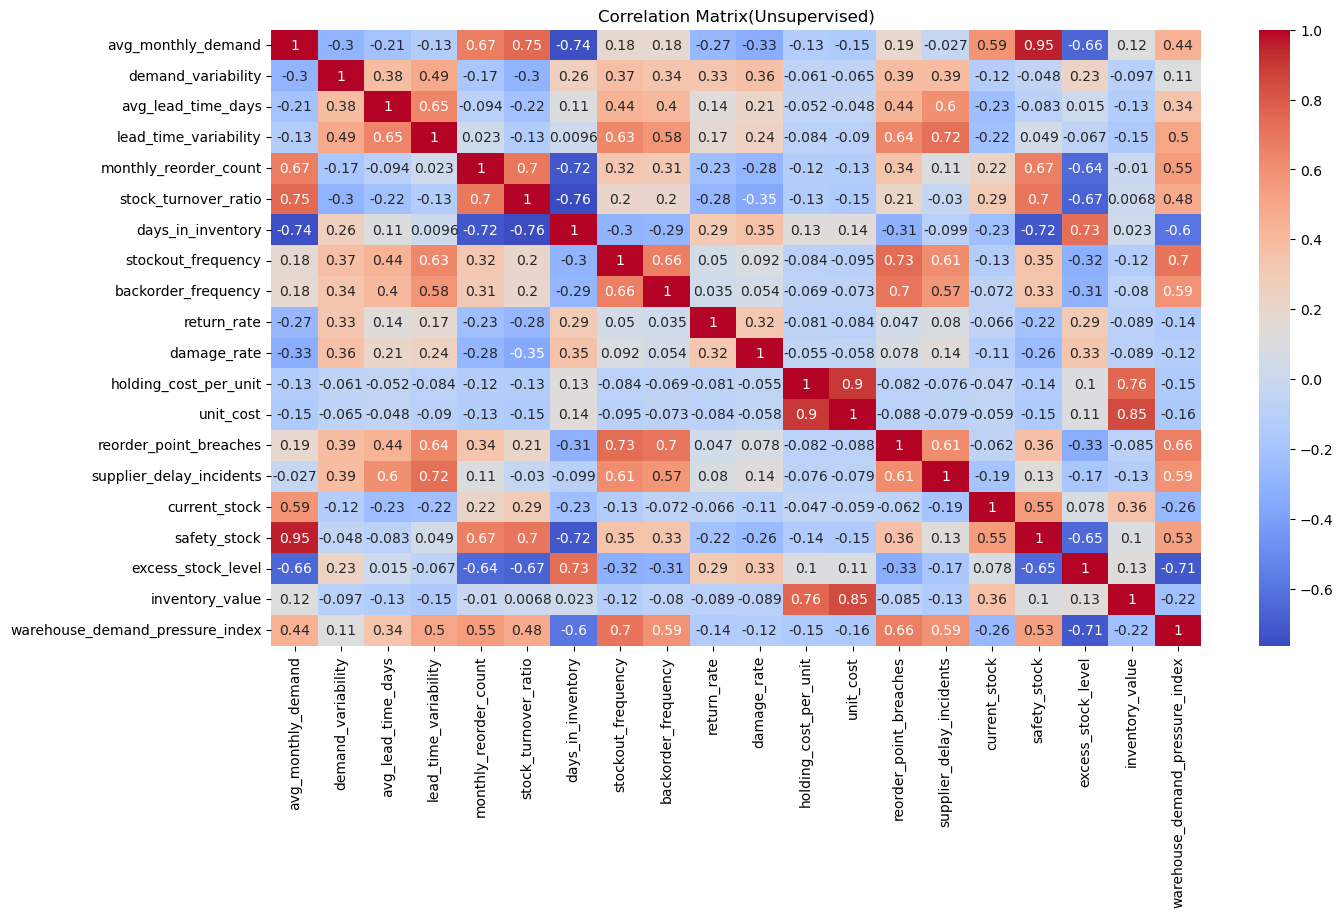

In [23]:
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix(Unsupervised)")
plt.show()

**The heatmap summarizes the correlation between all numerical features.**

**Positive Relationships -**
- avg_monthly_demand & stock_turnover_ratio (0.75):High demand → fast stock movement
- avg_monthly_demand & safety_stock (0.95):High demand → more safety stock
- stockout_frequency & backorder_frequency (0.66):More stockouts → more backorders
- unit_cost & inventory_value (0.85): Higher cost → higher inventory value.

**Negative Relationships -**
- days_in_inventory & stock_turnover_ratio (-0.76):More days in inventory → slower movement
- excess_stock_level & demand (-0.66):High excess stock → low demand
- warehouse_demand_pressure & excess_stock (-0.71):High demand pressure → less excess stock

**Weak / Low Correlation -**
- Some features have values near 0
- They are not strongly related
- Example: return_rate with many variables

In [37]:
df.head()

,category,subcategory,warehouse_zone,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,days_in_inventory,...,damage_rate,holding_cost_per_unit,unit_cost,reorder_point_breaches,supplier_delay_incidents,current_stock,safety_stock,excess_stock_level,inventory_value,warehouse_demand_pressure_index
0,Grocery,Snacks,B2,310,0.26,7.8,0.05,8,9.71,33,...,0.012,10.83,132.98,1,2,249,75,46,33112.02,161.12
1,Industrial,Electrical Parts,B1,455,0.16,4.8,0.08,8,11.55,26,...,0.007,45.57,1525.56,0,0,362,94,34,552252.72,141.27
2,Apparel,Jackets,B2,350,0.43,20.9,0.57,6,3.69,27,...,0.010,18.47,457.56,3,9,317,105,146,145046.52,238.29
3,Automotive,Lubricants,A1,121,0.33,4.6,0.12,1,0.54,120,...,0.017,168.71,1779.38,0,1,183,32,84,325626.54,87.90
4,Pharmaceutical,Medical Devices,A2,85,0.14,7.3,0.15,1,1.46,97,...,0.016,33.33,731.83,2,4,209,17,180,152952.47,86.85


In [38]:
# Drop columns where features are overlapping
drop_columns=[
    'subcategory',
    'days_in_inventory',
    'holding_cost_per_unit',
    'unit_cost',
    'reorder_point_breaches',
    'safety_stock'
]

In [39]:
categorical_columns=[
    'category',
    'warehouse_zone'
]

In [40]:
numerical_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'lead_time_variability',
    'monthly_reorder_count',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backout_frequency',
    'supplier_delay_incidents',
    'current_stock',
    'excess_stock_level',
    'inventory_value',
    'warehouse_demand_pressure_index'
]

In [41]:
df1=df.drop(columns=drop_columns)

In [42]:
df_encoded=pd.get_dummies(df1,columns=categorical_columns,drop_first=True)

In [43]:
X=df_encoded

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   avg_monthly_demand               4000 non-null   int64  
 1   demand_variability               4000 non-null   float64
 2   avg_lead_time_days               4000 non-null   float64
 3   lead_time_variability            4000 non-null   float64
 4   monthly_reorder_count            4000 non-null   int64  
 5   stock_turnover_ratio             4000 non-null   float64
 6   stockout_frequency               4000 non-null   int64  
 7   backorder_frequency              4000 non-null   int64  
 8   return_rate                      4000 non-null   float64
 9   damage_rate                      4000 non-null   float64
 10  supplier_delay_incidents         4000 non-null   int64  
 11  current_stock                    4000 non-null   int64  
 12  excess_stock_level  

In [46]:
X_scaled.shape

(4000, 29)

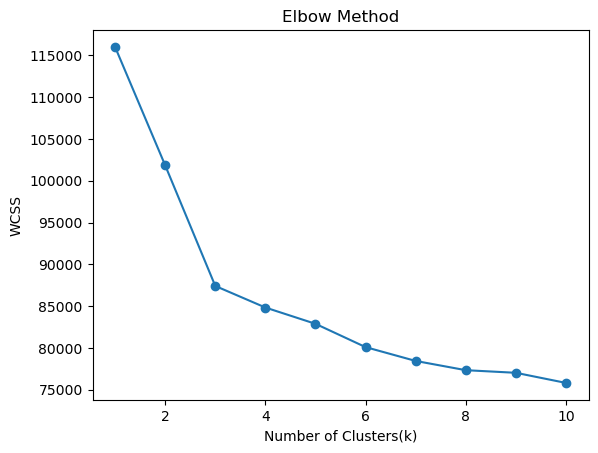

In [49]:
from sklearn.cluster import KMeans

wcss=[] # List to store WCSS (error) for different values of k
# loop through different values of k (number of clusters)
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)# Create K_Means Model
    kmeans.fit(X_scaled) # Train model on scaled data
    wcss.append(kmeans.inertia_) # store wcss(within cluster error)

# plot the elbow graph
plt.figure()
plt.plot(range(1,11),wcss,marker='o')# plot k vs wcss
plt.xlabel('Number of Clusters(k)') # X-axis -number of clueters
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

**The graph shows the best number of clusters. -**
- The bend is around 3–4 clusters
- So, data is best divided into 3 or 4 groups

In [51]:
kmeans_3=KMeans(n_clusters=3,random_state=42) #Create K-Means Model with 3 Clusters
df_encoded['Cluster_3']=kmeans_3.fit_predict(X_scaled) # Train model and assign cluster labels

kmeans_4=KMeans(n_clusters=4,random_state=42) # Create K_Means Model with 4 Clusters
df_encoded['Cluster_4']=kmeans_4.fit_predict(X_scaled)

In [52]:
df_encoded.groupby('Cluster_3').mean()
# Gropu the data by cluster 3 and caluculate the average of each column
# THIs helps us understand the characteristic of each cluster

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,category_Pharmaceutical,category_Stationery,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_4
Cluster_3,,,,,,,,,,,,,,,,,,,,,
0,80.417761,0.321537,9.712046,0.214193,1.530502,1.678077,0.688803,0.591506,0.034103,0.019467,...,0.119691,0.119691,0.136680,0.126641,0.115058,0.135907,0.118919,0.115830,0.12278,0.023166
1,525.839744,0.180513,6.045655,0.117215,6.488604,9.190506,0.722934,0.695157,0.022284,0.011046,...,0.135328,0.119658,0.126068,0.108262,0.110399,0.145299,0.128917,0.131054,0.12037,1.005698
2,372.649500,0.363359,15.480323,0.455803,5.946964,6.687586,6.193697,4.619523,0.029584,0.017012,...,0.118370,0.131437,0.118370,0.134512,0.129131,0.127594,0.128363,0.119908,0.12452,2.467333


**Cluster 3 -**
- High demand, high turnover
- Fast-selling products

In [53]:
df_encoded.groupby('Cluster_4').mean()
# Gropu the data by cluster 4 and calculate the average of each column
# THIs helps us understand the characteristic of each cluster

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,category_Pharmaceutical,category_Stationery,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_3
Cluster_4,,,,,,,,,,,,,,,,,,,,,
0,80.251362,0.321525,9.670817,0.213471,1.530739,1.675440,0.680934,0.585992,0.034105,0.019450,...,0.119066,0.119844,0.137743,0.126070,0.115953,0.136965,0.117510,0.115175,0.122957,0.000000
1,524.700714,0.179721,6.051143,0.116257,6.478571,9.176064,0.712857,0.683571,0.022296,0.011032,...,0.134286,0.120000,0.126429,0.108571,0.111429,0.144286,0.128571,0.130000,0.119286,1.002857
2,478.437229,0.393232,12.731025,0.421616,7.556999,8.479913,7.675325,5.708514,0.030045,0.016720,...,0.134199,0.122655,0.122655,0.122655,0.134199,0.150072,0.124098,0.118326,0.111111,1.988456
3,253.980707,0.330032,18.462862,0.491479,4.107717,4.664180,4.458199,3.353698,0.029066,0.017407,...,0.104502,0.139871,0.110932,0.147910,0.118971,0.102894,0.136656,0.125402,0.141479,1.967846


**Cluster 4 -**
- High stock or high delays
- Overstocked or problem products

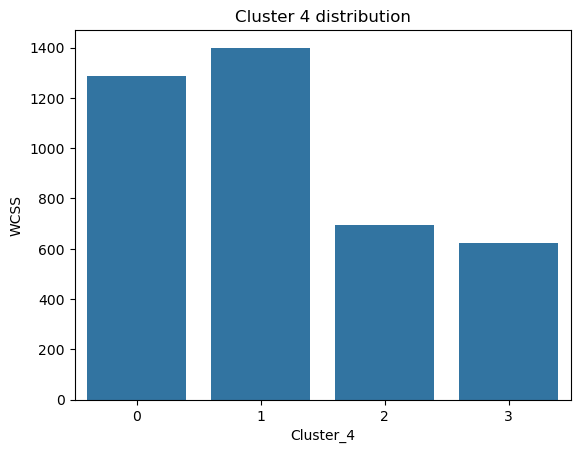

In [54]:
sns.countplot(x="Cluster_4", data=df_encoded)
plt.title("Cluster 4 distribution")
plt.xlabel("Cluster_4")
plt.ylabel("WCSS")
plt.show()

**Shows how many products are in each cluster -**
- Helps know which type of products are more

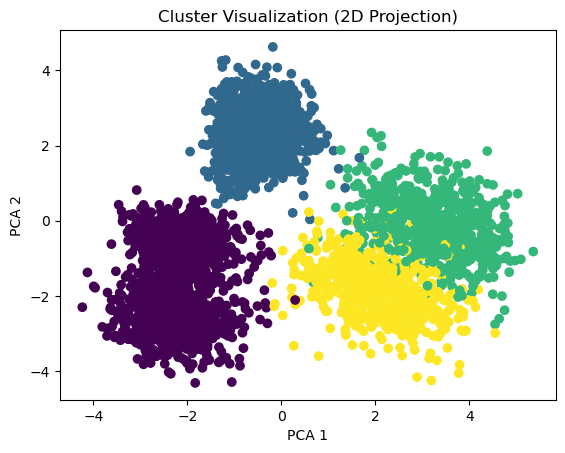

In [55]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2) # Reduce data to 2 dimensions for visualizations
X_pca =pca.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['Cluster_4'])
# plot points using the 2 pca components and color them by cluster
plt.title('Cluster Visualization (2D Projection)') # Title 
plt.xlabel('PCA 1')# Second Principal Component
plt.ylabel('PCA 2')# First Principal componenet
plt.show()

**PCA Graph -**
- Shows clusters in 2D view
- Separate groups = good clustering
- Mixed points = similar products

In [56]:
# core features doing because they are not working properly
core_features=[
    'avg_monthly_demand',
    'demand_variability',
    'avg_lead_time_days',
    'stock_turnover_ratio',
    'stockout_frequency',
    'backorder_frequency',
    'inventory_value',
    'warehouse_demand_pressure_index'
]

In [57]:
X_core=df_encoded[core_features]
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_scaled_core=scaler.fit_transform(X_core)

In [58]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=1.0,min_samples=10)
clusters=db.fit_predict(X_scaled_core)
df_encoded['DBSCAN_CLUSTER']=clusters

In [59]:
df_encoded['DBSCAN_CLUSTER'].value_counts()

DBSCAN_CLUSTER
 0    3814
-1     186
Name: count, dtype: int64

**DBSCAN Clustering -**
- Normal Clusters
- Groups of similar inventory items
- Outliers (-1):Unusual products
- Could be:Very high stock,Very low demand,Irregular behavior.

In [60]:
outliers=df_encoded[df_encoded['DBSCAN_CLUSTER']==-1]
# Filter and store all data points labeled as -1 (outliers) by DBSCAN
# These points that do not belong to any cluster

In [61]:
outliers.mean(numeric_only=True)
# Calculate the average values all all numeric columns for outliers.


avg_monthly_demand                    473.370968
demand_variability                      0.384247
avg_lead_time_days                     14.196774
lead_time_variability                   0.410000
monthly_reorder_count                   6.166667
stock_turnover_ratio                    7.610591
stockout_frequency                      6.354839
backorder_frequency                     5.419355
return_rate                             0.028898
damage_rate                             0.016586
supplier_delay_incidents                6.752688
current_stock                         400.731183
excess_stock_level                     58.112903
inventory_value                    548134.425860
warehouse_demand_pressure_index       222.695538
category_Automotive                     0.145161
category_Electronics                    0.150538
category_Grocery                        0.026882
category_Home & Kitchen                 0.123656
category_Industrial                     0.354839
category_Pharmaceuti

**Outliers Meaning -**
- These products:Have abnormal demand or stock,May cause loss or inefficiency

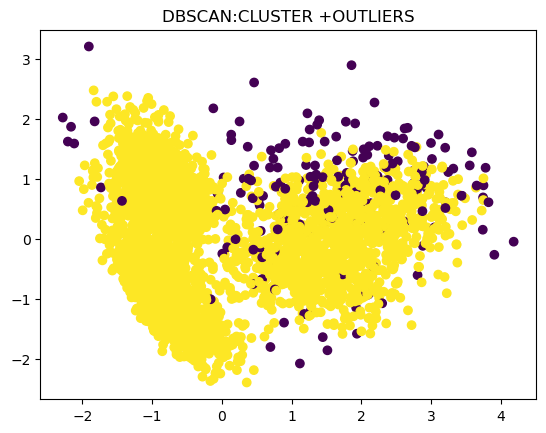

In [62]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
# reduce data t 2 dimensions for visualizations
X_pca=pca.fit_transform(X_scaled_core)
# transform the scaled data into 2d space 
plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,-1],c=df_encoded['DBSCAN_CLUSTER'])
# plot data points using 2d coordinates and color them by dbscan cluster
plt.title('DBSCAN:CLUSTER +OUTLIERS')# Title
plt.show()

**DBSCAN Cluster + Outliers Interpretation -**
- The yellow points represent normal products (clusters)
- These products have similar behavior (normal demand & stock)
- The purple points represent outliers (-1)
- These are unusual products

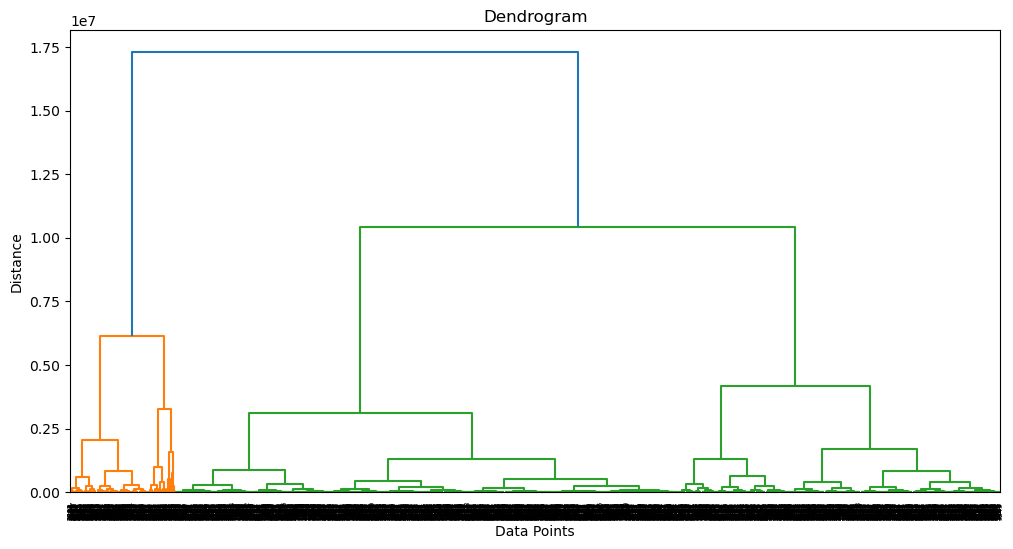

In [63]:
from scipy.cluster.hierarchy import dendrogram,linkage
linked=linkage(X,method='ward')
# Create hierarchical clustering linkage matrix using ward method
# Ward method minimizez variance within clusters
plt.figure(figsize=(12,6))
dendrogram(linked)
# plot dendogram tree like structure of clusterring
plt.title('Dendrogram') 
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

**Dendrogram -**
- Tree diagram showing cluster formation
- Best cut gives around 3–4 clusters.

In [64]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=4,linkage='ward')
# create hierarchical agglomerative clustering model with 4 clusters
# ward linkage clusters by minimizing vairance 
clusters=hc.fit_predict(X)
# train the model and assign cluster labels to each data point

- **Agglomerative clustering groups data step-by-step based on similarity, revealing structured relationships between observations.**

In [65]:
df_encoded['HC_Cluster']=clusters

In [66]:
df_encoded['HC_Cluster'].value_counts()

HC_Cluster
2    2171
0    1381
3     337
1     111
Name: count, dtype: int64

In [67]:
df_encoded.groupby('HC_Cluster').mean(numeric_only=True)

,avg_monthly_demand,demand_variability,avg_lead_time_days,lead_time_variability,monthly_reorder_count,stock_turnover_ratio,stockout_frequency,backorder_frequency,return_rate,damage_rate,...,warehouse_zone_A2,warehouse_zone_B1,warehouse_zone_B2,warehouse_zone_C1,warehouse_zone_C2,warehouse_zone_D1,warehouse_zone_D2,Cluster_3,Cluster_4,DBSCAN_CLUSTER
HC_Cluster,,,,,,,,,,,,,,,,,,,,,
0,359.507603,0.276307,9.839537,0.241224,4.805938,6.147495,2.233888,1.779870,0.027828,0.015185,...,0.128892,0.111513,0.116582,0.133961,0.126720,0.132513,0.128168,0.961622,1.078928,-0.046343
1,350.036036,0.247928,8.381081,0.188018,4.270270,5.311351,1.270270,1.153153,0.024261,0.013081,...,0.090090,0.171171,0.108108,0.135135,0.126126,0.171171,0.099099,0.540541,0.558559,-0.207207
2,301.921695,0.296564,10.907877,0.280129,4.648549,5.794169,2.798710,2.098572,0.029432,0.016342,...,0.130815,0.127130,0.116536,0.139567,0.124367,0.113772,0.116536,1.070014,1.285122,-0.016582
3,404.839763,0.265935,8.918101,0.215994,4.824926,6.287062,1.967359,1.810089,0.026463,0.014691,...,0.106825,0.124629,0.136499,0.127596,0.127596,0.121662,0.145401,0.875371,0.919881,-0.186944


**Cluster 0 :Low demand products**

**Cluster 1 :Regular products**

**Cluster 2 :High demand products**

**Cluster 3 :Overstocked or delayed products**

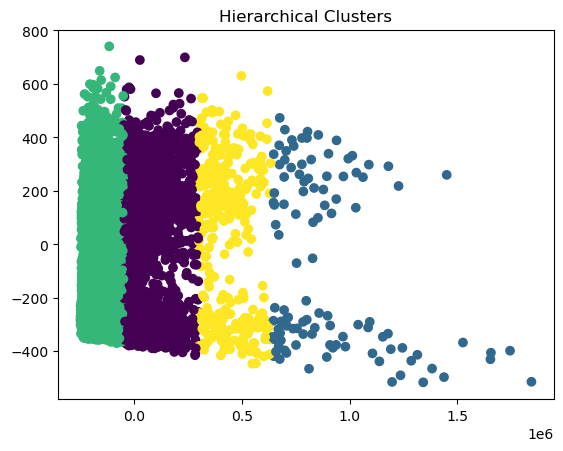

In [68]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

plt.figure()
# transform original data inot 2d space 
plt.scatter(X_pca[:,0],X_pca[:,1],c=df_encoded['HC_Cluster'])
# plot data points and color then based on hierarchical cluster labels
plt.title('Hierarchical Clusters')# title
plt.show()

**Hierarchical Clusters Interpretation -**
- The graph shows 4 different colored groups
- Each color = one cluster.

**What the graph shows -**

**Green Cluster:Points are closely packed on the left**
- Low value / low demand products**

**Purple Cluster:Large group in the middle**
- Normal products (average demand & stock)**
  
**Yellow Cluster :Slightly spread out -**
- Moderate to high demand products**

**Blue Cluster:Widely scattered on the right -**
- High value or unusual products.**